# Forecast Evaluation: Backfill MAPE Analysis

The current Production models were trained on data up to **December 2025**.
Destatis has since published **January, February, and March 2026**, which we ingested into Postgres in Phase E.

This notebook:
1. Loads each state's Production model from the MLflow registry
2. Forecasts 3 months ahead (the "backfill" period)
3. Compares against the real arrivals values now in Postgres
4. Compares the new (out-of-sample) MAPE against the training MAPE stored in the registry

Exploratory — not part of the production retrain flow.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

from bundeshost.data.pipeline import get_tourism_data
from bundeshost.modeling.predict import forecast_state, load_model
from bundeshost.config import STATES, MODEL_ORDERS

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

TARGET_DATES = pd.to_datetime(["2026-01-01", "2026-02-01", "2026-03-01"])

## 1. Load actuals from Postgres

In [14]:
df = get_tourism_data()

actuals = (
    df[df["date"].isin(TARGET_DATES)]
    .pivot(index="date", columns="state", values="arrivals")
    .sort_index()
)
actuals

state,Baden-Württemberg,Bayern,Berlin,Brandenburg,Bremen,Hamburg,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Nordrhein-Westfalen,Rheinland-Pfalz,Saarland,Sachsen,Sachsen-Anhalt,Schleswig-Holstein,Thüringen
date,,,,,,,,,,,,,,,,
2026-01-01,1276893.0,2287209.0,767454.0,254474.0,94085.0,498721.0,956746.0,267333.0,715362.0,1635981.0,352890.0,67611.0,426821.0,157027.0,334518.0,194960.0
2026-02-01,1373179.0,2529909.0,813382.0,285443.0,98694.0,537989.0,1029442.0,354235.0,812046.0,1750101.0,407700.0,72483.0,438266.0,171932.0,405052.0,200208.0
2026-03-01,1668755.0,2754390.0,1016673.0,348303.0,117515.0,643663.0,1185169.0,503357.0,1074834.0,2023398.0,578762.0,91311.0,581011.0,237300.0,619929.0,271378.0


## 2. Generate forecasts from current Production models

In [15]:
forecasts = {}
for state in STATES:
    try:
        fc = forecast_state(state, horizon=3).set_index("date")["forecast"]
        forecasts[state] = fc
    except Exception as e:
        print(f"{state}: FAILED -- {e}")

forecasts_df = pd.DataFrame(forecasts)
forecasts_df = forecasts_df.loc[forecasts_df.index.isin(TARGET_DATES)]
forecasts_df

,Baden-Württemberg,Bayern,Berlin,Brandenburg,Bremen,Hamburg,Hessen,Mecklenburg-Vorpommern,Niedersachsen,Nordrhein-Westfalen,Rheinland-Pfalz,Saarland,Sachsen,Sachsen-Anhalt,Schleswig-Holstein,Thüringen
date,,,,,,,,,,,,,,,,
2026-01-01,1.440591e+06,2.557412e+06,827607.062656,264253.986990,103977.852525,540200.360061,1.028475e+06,303605.955946,8.117693e+05,1.764822e+06,393148.376447,73771.318772,460233.611740,173145.330625,384575.395961,216162.226107
2026-02-01,1.513865e+06,2.714570e+06,882020.778553,288815.380895,112660.471888,589285.944464,1.063964e+06,360055.777008,8.918096e+05,1.829236e+06,431322.181859,77387.661413,475482.089092,187482.770252,454764.986145,223941.742282
2026-03-01,1.709280e+06,2.912315e+06,966936.144451,348602.279929,123997.105907,659605.353404,1.189995e+06,472445.479628,1.093438e+06,2.067665e+06,570572.943342,89962.818718,563894.998718,228244.797149,594816.196020,268275.324750


## 3. New MAPE per state (3 months of ground truth)

In [16]:
common_states = actuals.columns.intersection(forecasts_df.columns)
a = actuals[common_states]
f = forecasts_df[common_states]

ape = ((a - f).abs() / a.abs()) * 100

results = pd.DataFrame({
    "mape_pct": ape.mean(axis=0),
    "mean_actual": a.mean(axis=0),
    "mean_forecast": f.mean(axis=0),
})
results["bias_pct"] = ((results["mean_forecast"] - results["mean_actual"]) / results["mean_actual"]) * 100
results.index.name = "state"
results.round(2)

,mape_pct,mean_actual,mean_forecast,bias_pct
state,,,,
Baden-Württemberg,8.50,1439609.00,1554578.89,7.99
Bayern,8.28,2523836.00,2728099.02,8.09
Berlin,7.06,865836.33,892188.00,3.04
Brandenburg,1.70,296073.33,300557.22,1.51
Bremen,10.06,103431.33,113545.14,9.78
Hamburg,6.78,560124.33,596363.89,6.47
Hessen,3.75,1057119.00,1094144.48,3.50
Mecklenburg-Vorpommern,7.12,374975.00,378702.40,0.99
Niedersachsen,8.34,867414.00,932338.88,7.48


## 4. Model metadata (variant + orders)

In [17]:
model_lookup = {}
for state in STATES:
    try:
        _, raw_name = load_model(state)
        variant = raw_name.rsplit("_", 1)[-1]
        order, seasonal_order = MODEL_ORDERS[state][variant]
        model_lookup[state] = {
            "variant": variant,
            "order": str(order),
            "seasonal_order": str(seasonal_order),
        }
    except Exception as e:
        model_lookup[state] = {"variant": "ERROR", "order": str(e)[:50], "seasonal_order": ""}

model_info_df = pd.DataFrame(model_lookup).T
model_info_df.index.name = "state"
model_info_df

,variant,order,seasonal_order
state,,,
Baden-Württemberg,sarima,"(2, 1, 2)","(1, 1, 1, 12)"
Bayern,sarimax,"(1, 1, 2)","(1, 1, 1, 12)"
Berlin,sarima,"(2, 1, 2)","(1, 1, 1, 12)"
Brandenburg,sarima,"(4, 1, 4)","(1, 1, 1, 12)"
Bremen,sarima,"(3, 1, 2)","(0, 1, 1, 12)"
Hamburg,sarimax,"(1, 1, 2)","(0, 1, 1, 12)"
Hessen,sarimax,"(2, 1, 3)","(0, 1, 1, 12)"
Mecklenburg-Vorpommern,sarimax,"(1, 1, 1)","(1, 1, 1, 12)"
Niedersachsen,sarimax,"(4, 1, 3)","(0, 1, 1, 12)"


## 5. Training MAPE from the MLflow registry

In [18]:
client = MlflowClient()

prod_tags = {}
for state in STATES:
    registered_name = f"bundeshost-{state}"
    try:
        versions = client.get_latest_versions(registered_name, stages=["Production"])
        if versions and versions[0].tags.get("production_mape"):
            prod_tags[state] = float(versions[0].tags["production_mape"])
        else:
            prod_tags[state] = None
    except Exception as e:
        print(f"{state}: {e}")
        prod_tags[state] = None

train_mape = pd.Series(prod_tags, name="train_mape_pct")
train_mape.index.name = "state"
train_mape.round(2)

/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_78979/1744158563.py:7: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  versions = client.get_latest_versions(registered_name, stages=["Production"])


state
Baden-Württemberg         4.43
Bayern                    4.70
Berlin                    5.82
Brandenburg               2.90
Bremen                    4.69
Hamburg                   3.32
Hessen                    3.72
Mecklenburg-Vorpommern    5.88
Niedersachsen             5.17
Nordrhein-Westfalen       3.44
Rheinland-Pfalz           5.06
Saarland                  5.62
Sachsen                   6.19
Sachsen-Anhalt            4.19
Schleswig-Holstein        5.89
Thüringen                 3.81
Name: train_mape_pct, dtype: float64

## 6. Comparison: train MAPE vs new (backfill) MAPE

Sorted by **smallest drift first** — the states at the top are still fine; the states at the bottom have drifted the most and would benefit most from a retrain.

In [19]:
comparison = (
    results
    .join(model_info_df)
    .join(train_mape)
)
comparison["delta_pct_pts"] = comparison["mape_pct"] - comparison["train_mape_pct"]

comparison = comparison[[
    "variant", "order", "seasonal_order",
    "train_mape_pct", "mape_pct", "delta_pct_pts",
    "bias_pct", "mean_actual", "mean_forecast",
]].round(2)

comparison = comparison.sort_values("delta_pct_pts", ascending=True)
comparison

,variant,order,seasonal_order,train_mape_pct,mape_pct,delta_pct_pts,bias_pct,mean_actual,mean_forecast
state,,,,,,,,,
Brandenburg,sarima,"(4, 1, 4)","(1, 1, 1, 12)",2.90,1.70,-1.20,1.51,296073.33,300557.22
Hessen,sarimax,"(2, 1, 3)","(0, 1, 1, 12)",3.72,3.75,0.04,3.50,1057119.00,1094144.48
Saarland,sarimax,"(1, 1, 1)","(1, 1, 1, 12)",5.62,5.78,0.16,4.20,77135.00,80373.93
Sachsen,sarima,"(2, 1, 2)","(1, 1, 1, 12)",6.19,6.42,0.23,3.70,482032.67,499870.23
Rheinland-Pfalz,sarimax,"(2, 1, 1)","(1, 1, 1, 12)",5.06,6.21,1.15,4.16,446450.67,465014.50
Berlin,sarima,"(2, 1, 2)","(1, 1, 1, 12)",5.82,7.06,1.23,3.04,865836.33,892188.00
Mecklenburg-Vorpommern,sarimax,"(1, 1, 1)","(1, 1, 1, 12)",5.88,7.12,1.24,0.99,374975.00,378702.40
Nordrhein-Westfalen,sarimax,"(1, 1, 1)","(1, 1, 1, 12)",3.44,4.86,1.42,4.66,1803160.00,1887241.21
Niedersachsen,sarimax,"(4, 1, 3)","(0, 1, 1, 12)",5.17,8.34,3.18,7.48,867414.00,932338.88


## 7. Visualize the drift

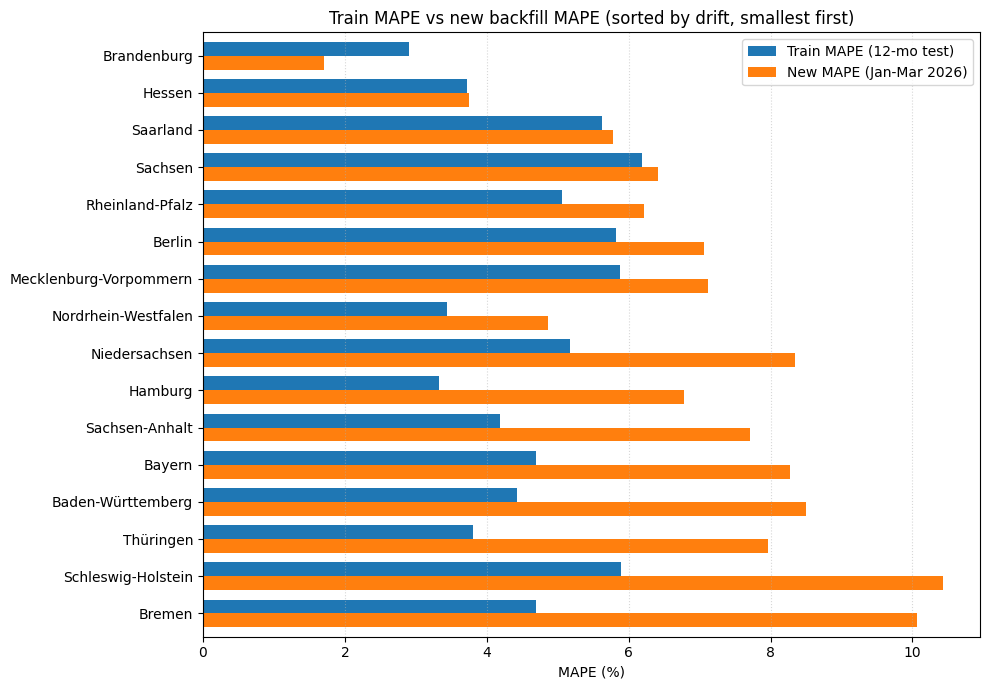

In [20]:
plot_df = comparison[["train_mape_pct", "mape_pct"]].copy()
plot_df.columns = ["Train MAPE (12-mo test)", "New MAPE (Jan-Mar 2026)"]

ax = plot_df.plot(kind="barh", figsize=(10, 7), width=0.75)
ax.set_xlabel("MAPE (%)")
ax.set_ylabel("")
ax.set_title("Train MAPE vs new backfill MAPE (sorted by drift, smallest first)")
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()